In [1]:
import pandas as pd
import numpy as np
from typing import List, Dict, Any

from src.build_network import ResIN
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from adjustText import adjust_text

import yaml
with open("../../src/configs.yml", "r") as configs:
    configs = yaml.safe_load(configs)

ROOTPATH = configs["ROOTPATH"]
ROOTPATH2 = configs["ROOTPATH2"]
OUTPATH = "../../output/results-summary-090924/"

print(configs)

{'ROOTPATH': '/Users/yijingch/Documents/GITHUB/broken-egg-polarization/', 'GITHUBPATH': '/Users/yijingch/Documents/GITHUB/', 'ROOTPATH2': '/Users/yijingch/Dropbox/CSS 2023 Attitude Networks/ANES/Cumulative'}


In [2]:
anes_all = pd.read_csv(ROOTPATH + "data/anes_out_090624.csv").drop(columns=["Unnamed: 0"])
YEARS = [2000, 2004, 2008, 2012, 2016, 2020]
anes_all = anes_all[anes_all["year"].isin(YEARS)]
anes_all["ft_rep_net"] = anes_all["ft_rep"] - anes_all["ft_dem"] # compute the net value of ft rep/dem
# internet access
anes_all["it_access"] = anes_all["it_access"].replace(5, 0)
anes_all["it_access"] = anes_all["it_access"].replace(9, np.NaN)

# adjust reverse scale so that the direction of answers are aligned
anes_all["spend_serv"] = anes_all["spend_serv"].map(lambda x: 8-x)
anes_all["abort"] = anes_all["abort"].map(lambda x: 5-x)
anes_all.head()


,year,gov_health,guar_jobs,us_isolate,aid_black,abort,spend_serv,def_spend,aff_act_1,aff_act_2,...,hw_blacks,hw_his,hw_asian,it_access,it_campaign,left_right,lbrl_cnsv,dem_rep,weights,ft_rep_net
11295,2000,5.0,6.0,NaN,NaN,3.0,5.0,6.0,5.0,5.0,...,4.0,4.0,4.0,1.0,1.0,NaN,NaN,5.0,1.2886,16.0
11296,2000,NaN,NaN,2.0,NaN,1.0,NaN,NaN,5.0,5.0,...,4.0,7.0,1.0,1.0,5.0,NaN,NaN,3.0,0.8959,NaN
11297,2000,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,...,1.0,6.0,5.0,1.0,5.0,NaN,NaN,1.0,1.0454,-30.0
11298,2000,NaN,NaN,2.0,NaN,1.0,NaN,NaN,5.0,5.0,...,5.0,4.0,1.0,0.0,5.0,NaN,5.0,3.0,0.6005,-5.0
11299,2000,NaN,NaN,NaN,NaN,2.0,NaN,NaN,5.0,5.0,...,4.0,5.0,1.0,0.0,5.0,NaN,6.0,7.0,1.9270,70.0


In [3]:
PARTISAN_LABEL_CATG = {
    1: -1, 2: -1, 3: -1, 
    4: 0,
    5: 1, 6: 1, 7: 1,
}

anes_all["dem_rep_3"] = anes_all["dem_rep"].map(lambda x: PARTISAN_LABEL_CATG[x] if not np.isnan(x) else np.NaN)
anes_all = anes_all[anes_all["dem_rep_3"].notna()]

In [4]:
NODE_COLS = [
    "gov_health", "guar_jobs", "abort", "aid_black", "spend_serv"
]

COV_COLS = ["ft_rep_net"]

# should all be poisitive
anes_all[NODE_COLS + COV_COLS].corr()

,gov_health,guar_jobs,abort,aid_black,spend_serv,ft_rep_net
gov_health,1.000000,0.548873,0.295701,0.462339,0.539122,0.455132
guar_jobs,0.548873,1.000000,0.204695,0.562729,0.530498,0.424705
abort,0.295701,0.204695,1.000000,0.237852,0.247302,0.303017
aid_black,0.462339,0.562729,0.237852,1.000000,0.484939,0.433782
spend_serv,0.539122,0.530498,0.247302,0.484939,1.000000,0.473294
ft_rep_net,0.455132,0.424705,0.303017,0.433782,0.473294,1.000000


Lelkes, Y. (2018, April). Affective polarization and ideological sorting: A reciprocal, albeit weak, relationship. In The Forum (Vol. 16, No. 1, pp. 67-79). De Gruyter.

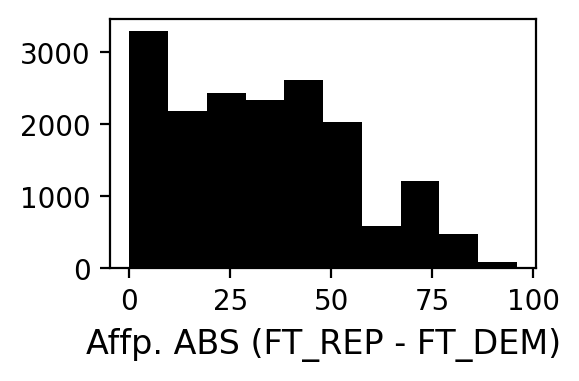

In [5]:
# an easy shortcut for affective polarization is just to get the absolute difference
anes_all["ft_rep_net_abs"] = anes_all["ft_rep_net"].map(lambda x: abs(x))

fig,ax = plt.subplots(figsize=(3,2))
plt.hist(anes_all["ft_rep_net_abs"], color="black", bins=10)
plt.xlabel("Affp. ABS (FT_REP - FT_DEM)", fontsize=12)
plt.tight_layout()


## the old linear measure of ideological consistency

In [6]:
max_val = np.sum([anes_all[col].max() for col in NODE_COLS])
anes_all["lnr_ideo_csst"] = anes_all.apply(lambda x: abs(1-2*np.nansum([x[col] for col in NODE_COLS]/max_val)), axis=1)

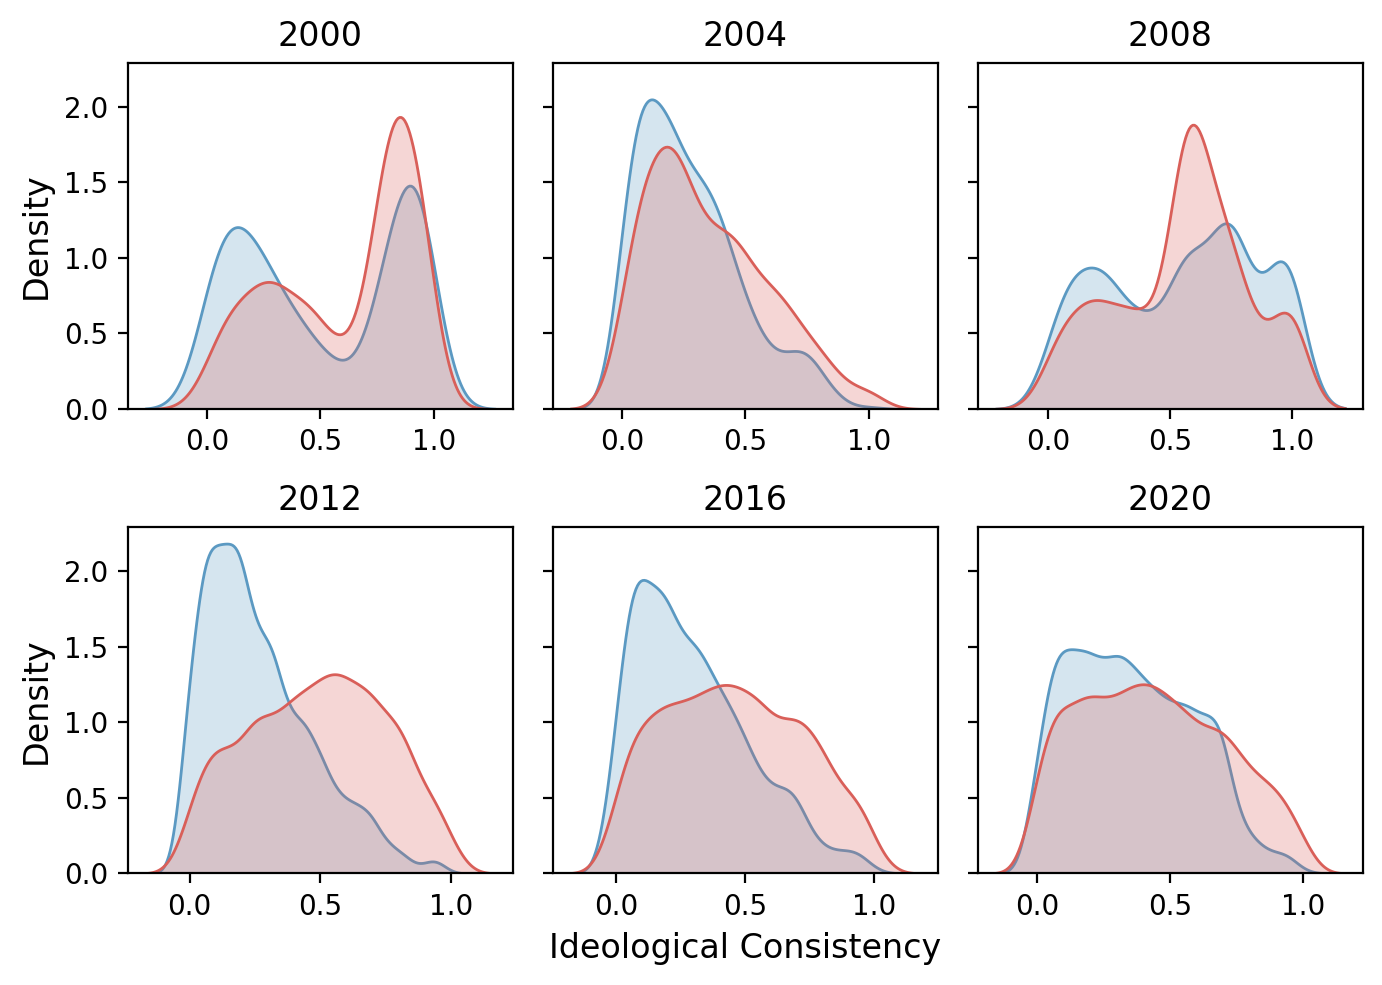

In [7]:
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(7,5), sharey=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    anes_year = anes_all[anes_all["year"]==year]
    dem_anes_year = anes_year[anes_year["dem_rep_3"]==-1]
    rep_anes_year = anes_year[anes_year["dem_rep_3"]==1]
    sns.kdeplot(dem_anes_year["lnr_ideo_csst"], color="#5B99C2", ax=ax[i], fill=True, label="DEM")
    sns.kdeplot(rep_anes_year["lnr_ideo_csst"], color="#D95F59", ax=ax[i], fill=True, label="REP")
    ax[i].set_title(year, fontsize=12)
    # ax[i].set_xlim(0,1)
    if i in [0,3]:
        ax[i].set_ylabel("Density", fontsize=12)
    if i == 4: 
        ax[i].set_xlabel("Ideological Consistency", fontsize=12)
    else:
        ax[i].set_xlabel("")
plt.tight_layout()



## Resin Measure of ideological consistency

In [8]:
RESIN_DICT = {}
NEUTRAL_VAL_DICT = {}
for year in YEARS:
    print("processing:", year)
    anes_year = anes_all[anes_all["year"]==year].copy()
    anes_year = anes_year[NODE_COLS + COV_COLS]
    resin = ResIN(df=anes_year, node_cols=NODE_COLS)
    resin.make_graph(square_corr=False, remove_nan=True)
    resin.compute_covariates(covariate_cols=COV_COLS)
    resin.adjust_coordinates()
    resin.get_item_size()
    resin.set_edge_distance()
    RESIN_DICT[year] = resin
    NEUTRAL_VAL_DICT[year] = np.nanmean(anes_year["ft_rep_net"])

processing: 2000
processing: 2004
processing: 2008
processing: 2012
processing: 2016
processing: 2020


In [9]:
YEAR_RESPONSE_DICT = {}

for year in YEARS:
    YEAR_RESPONSE_DICT[year] = anes_all[anes_all["year"]==year].to_dict("index")

In [10]:
YEAR_RESPONSE_DICT[2020]

{28331: {'year': 2020,
  'gov_health': 7.0,
  'guar_jobs': 7.0,
  'us_isolate': 2.0,
  'aid_black': 7.0,
  'abort': 3.0,
  'spend_serv': 7.0,
  'def_spend': 7.0,
  'aff_act_1': 5.0,
  'aff_act_2': 5.0,
  'gay_discr': 1.0,
  'immigrat': 5.0,
  'spend_poor': 3.0,
  'spend_child': nan,
  'spend_crime': 3.0,
  'spend_school': 3.0,
  'spend_welfare': 3.0,
  'spend_env': 3.0,
  'spend_socsec': 2.0,
  'black_fairjob': nan,
  'import_lim': 1.0,
  'death_pen': 1.0,
  'gun_own': 2.0,
  'def_spend_D': nan,
  'aid_black_D': 1.0,
  'gov_health_D': 1.0,
  'spend_serv_D': 7.0,
  'guar_jobs_D': nan,
  'lib_con_D': 1.0,
  'abort_D': 4.0,
  'def_spend_R': nan,
  'aid_black_R': 5.0,
  'gov_health_R': 7.0,
  'spend_serv_R': 4.0,
  'guar_jobs_R': nan,
  'lib_con_R': 5.0,
  'abort_R': 2.0,
  'lib_con': 6.0,
  'pid': 7.0,
  'egal_1': 1.0,
  'egal_2': 1.0,
  'auth_1': 3.0,
  'auth_2': 3.0,
  'auth_3': 1.0,
  'auth_4': 3.0,
  'rac_res_1': 1.0,
  'rac_res_2': 1.0,
  'rac_res_3': 1.0,
  'rac_res_4': 5.0,
  'pena

In [33]:
def get_density_weighted(g):
    s = np.sum([e[2]["weight"] for e in g.edges(data=True)])
    n = len(g.nodes())
    denm = n*(n-1)/2
    return s/denm 

def prepare_respondent_df(year, issues=NODE_COLS):
    resin = RESIN_DICT[year]
    response_dict = YEAR_RESPONSE_DICT[year]
    g = resin.g 
    
    respondent_df = pd.DataFrame()
    sort_ls = []
    affp_ls = []
    part_ls = []
    ln_sort_ls = []
    for _, response in response_dict.items():
        sub_nodes = [f"{x}:{response[x]}" for x in issues if not np.isnan(response[x])]
        subg = g.subgraph(sub_nodes) # get subgraph 
        sort_ls.append(get_density_weighted(subg))
        affp_ls.append(response["ft_rep_net_abs"])
        part_ls.append(response["dem_rep_3"])
        ln_sort_ls.append(response["lnr_ideo_csst"])
    respondent_df["sort"] = sort_ls 
    respondent_df["affp"] = affp_ls
    respondent_df["part"] = part_ls
    respondent_df["ln_sort"] = ln_sort_ls
    respondent_df.dropna(inplace=True)
    return respondent_df


In [34]:
respondent_df_all = pd.DataFrame()
for year in YEARS:
    print(year, "preparing repondent df")
    rdf = prepare_respondent_df(year)
    rdf["year"] = year
    respondent_df_all = pd.concat([rdf, respondent_df_all])
    print("# of res:", len(rdf))

2000 preparing repondent df
# of res: 871
2004 preparing repondent df
# of res: 1011
2008 preparing repondent df
# of res: 925
2012 preparing repondent df


/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm


# of res: 4445
2016 preparing repondent df
# of res: 3198
2020 preparing repondent df


/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm
/var/folders/6j/_fm4pddj4fd8_hv1t_6zy1r80000gn/T/ipykernel_40228/746556034.py:5: RuntimeWarning: invalid value encountered in double_scalars
  return s/denm


# of res: 4872


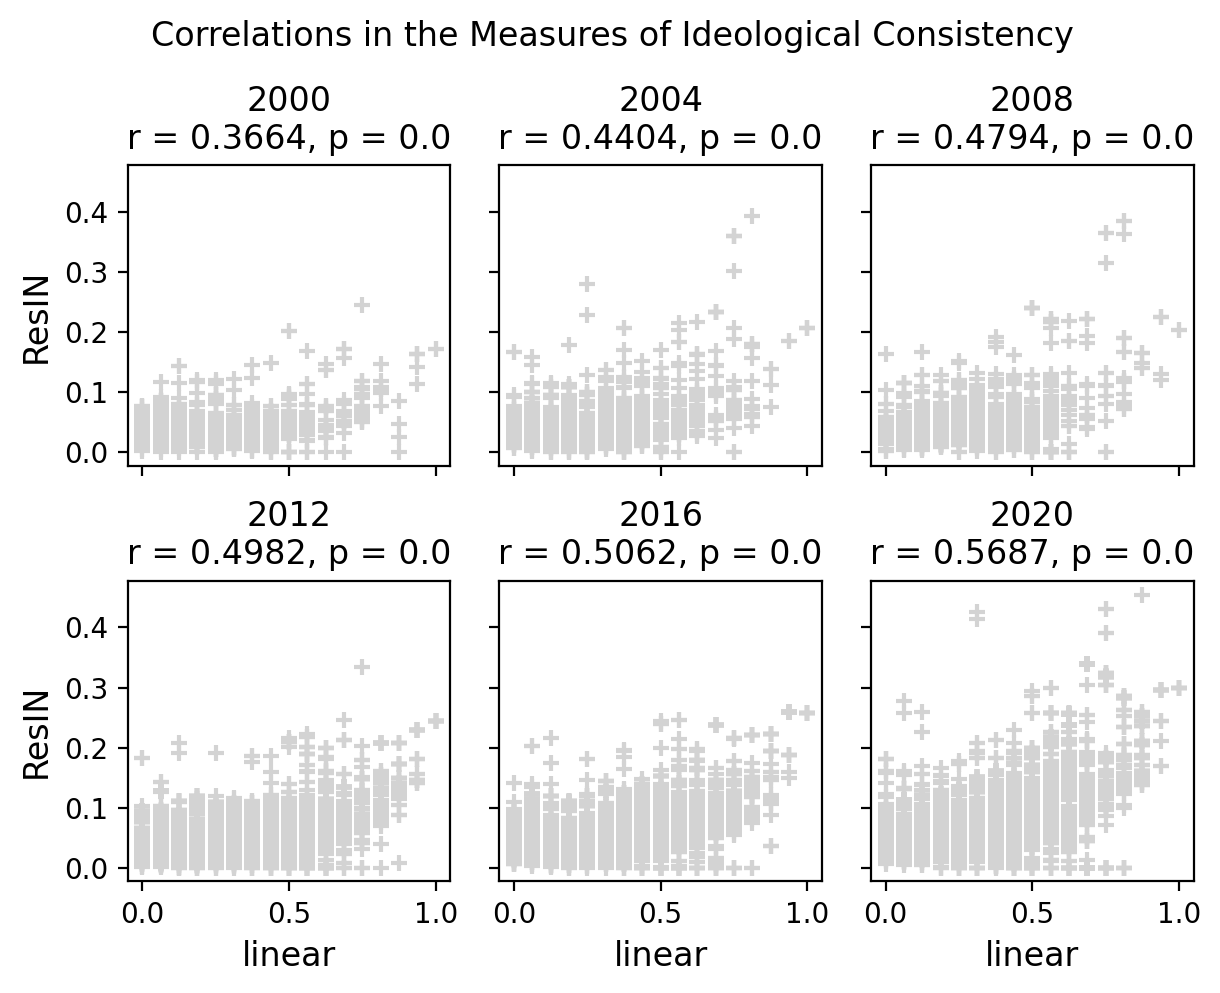

In [48]:
from scipy.stats import pearsonr
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(6.2,5), sharey=True, sharex=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    res_year = respondent_df_all[respondent_df_all["year"]==year]
    ax[i].scatter(res_year["ln_sort"], res_year["sort"], color="lightgrey", marker="+")
    # ax[i].hist2d(res_year["ln_sort"], res_year["sort"], bins=[np.arange(0, 1, .1), np.arange(0, .5, .05)])
    # dem_res = res_year[res_year["part"]==-1]
    # rep_res = res_year[res_year["part"]==1]
    # ax[i].scatter(dem_res["ln_sort"], dem_res["sort"], color="#5B99C2")
    # ax[i].scatter(rep_res["ln_sort"], rep_res["sort"], color="#D95F59")
    r,p = pearsonr(res_year["ln_sort"], res_year["sort"])
    ax[i].set_title(f"{year}\nr = {round(r,4)}, p = {round(p,4)}", fontsize=12)
    # ax[i].set_xlim(0,1)
    if i in [0,3]:
        ax[i].set_ylabel("ResIN", fontsize=12)
    if i > 2: 
        ax[i].set_xlabel("linear", fontsize=12)
    else:
        ax[i].set_xlabel("")
plt.suptitle("Correlations in the Measures of Ideological Consistency", fontsize=12)
plt.tight_layout()


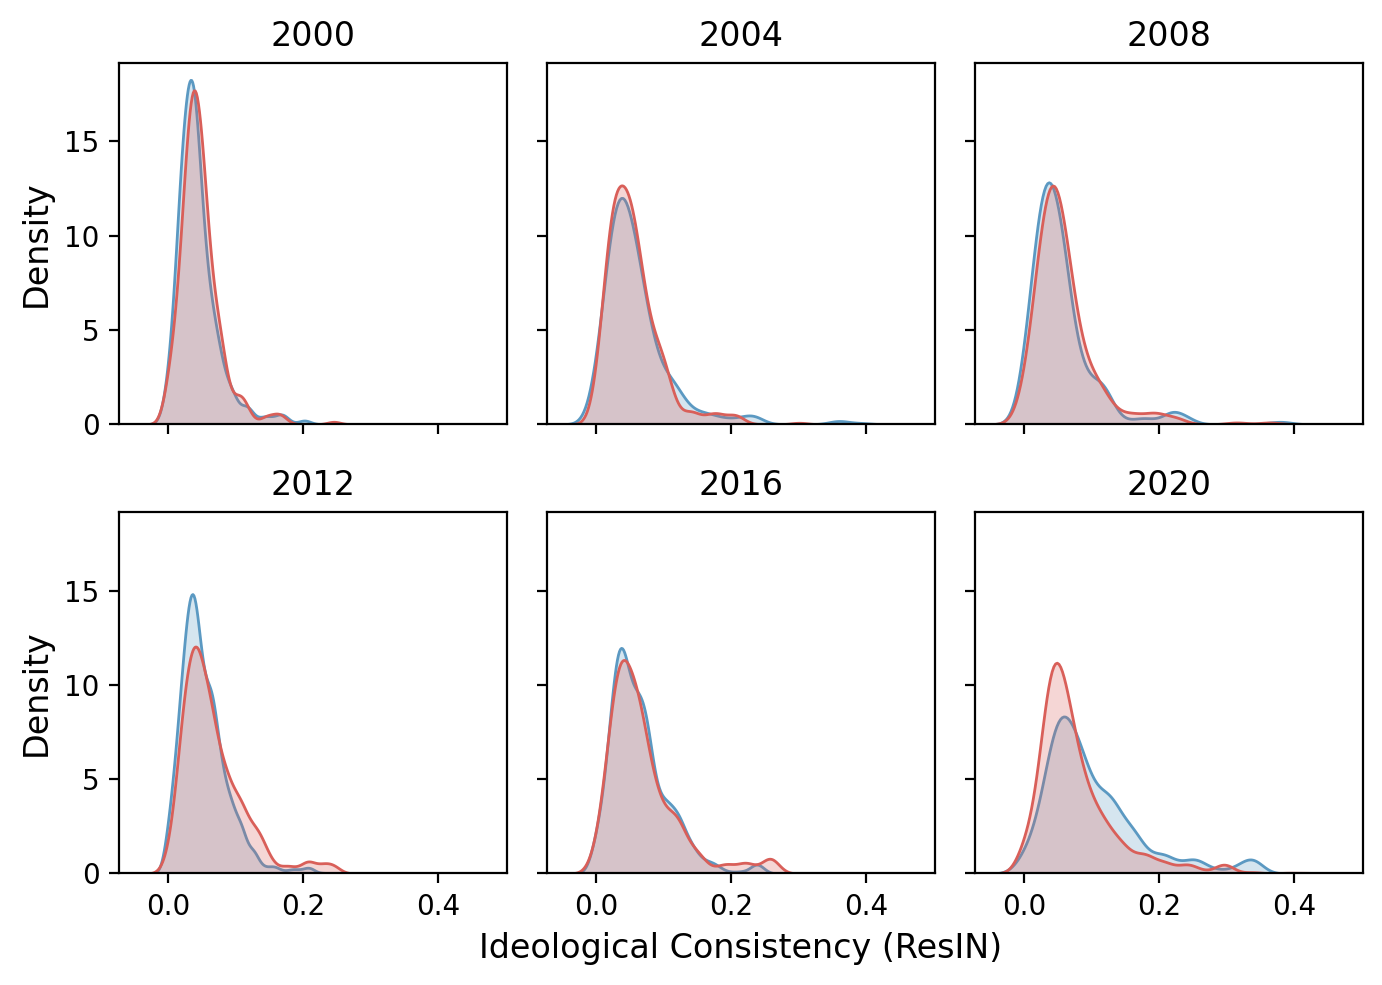

In [32]:
fig,ax = plt.subplots(ncols=3, nrows=2, figsize=(7,5), sharey=True, sharex=True)
ax = [x for ls in ax for x in ls]
for i,year in enumerate(YEARS):
    res_year = respondent_df_all[respondent_df_all["year"]==year]
    dem_res = res_year[res_year["part"]==-1]
    rep_res = res_year[res_year["part"]==1]
    sns.kdeplot(dem_res["sort"], color="#5B99C2", ax=ax[i], fill=True, label="DEM")
    sns.kdeplot(rep_res["sort"], color="#D95F59", ax=ax[i], fill=True, label="REP")
    ax[i].set_title(year, fontsize=12)
    # ax[i].set_xlim(0,1)
    if i in [0,3]:
        ax[i].set_ylabel("Density", fontsize=12)
    if i == 4: 
        ax[i].set_xlabel("Ideological Consistency (ResIN)", fontsize=12)
    else:
        ax[i].set_xlabel("")
plt.tight_layout()

